# Jump Parameter Estimation for M2

1. Define jumps as weekly Brent returns below threshold
2. Fit logistic: OVX to P(jump in next 21 days)
3. Calibrate single-parameter eta from empirical jump sizes
4. Final mapping: `ovx_to_jump_params(ovx)` returns (lambda, mu_J, sigma_J)

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

## 1. Load & Merge Data

In [37]:
oil_price = pd.read_csv('../data/processed/Oil/oil_prices_datastream.csv')
ovx = pd.read_csv('../data/processed/Macroeconomic_variables/OVXCLS.csv')

oil_price['date'] = pd.to_datetime(oil_price['date'], errors='coerce')
ovx['date'] = pd.to_datetime(ovx['date'], errors='coerce')

df = pd.merge(oil_price, ovx, on='date', how='inner').sort_values('date').reset_index(drop=True)
df.ffill(inplace=True)

price_col = 'price' if 'price' in df.columns else df.columns[1]
df['oil_ret_1d'] = np.log(df[price_col] / df[price_col].shift(1))
df.dropna(inplace=True)

print(f"Sample: {df['date'].min().date()} to {df['date'].max().date()}")
print(f"Observations: {len(df)}")

# Weekly resample
dfw = df.set_index('date').resample('W').last().copy()
dfw['oil_ret_w'] = np.log(dfw[price_col] / dfw[price_col].shift(1))
dfw['OVX_lag'] = dfw['OVXCLS'].shift(1)
dfw = dfw.dropna()


Sample: 2007-05-11 to 2025-01-01
Observations: 4604


/var/folders/wy/gjw_3_n51t748hfngpz4zf0w0000gn/T/ipykernel_87516/3292798446.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  oil_price['date'] = pd.to_datetime(oil_price['date'], errors='coerce')


## 2. Define Jumps & Forward-Looking Variables

In [35]:
from scipy.optimize import curve_fit

threshold = -0.10  # adjust based on output above
dfw['is_jump'] = (dfw['oil_ret_w'] < threshold).astype(int)

# Rolling realized jump frequency (26 week window)
window = 52
dfw['realized_lambda'] = dfw['is_jump'].rolling(window).mean()
dfw['OVX_avg'] = dfw['OVXCLS'].rolling(window).mean()
df_fit = dfw.dropna(subset=['realized_lambda', 'OVX_avg'])

def sigmoid(x, L, k, x0):
    return L / (1 + np.exp(-k * (x - x0)))

popt, _ = curve_fit(
    sigmoid,
    df_fit['OVX_avg'].values,
    df_fit['realized_lambda'].values,
    p0=[0.15, 0.1, 40],
    bounds=([0, 0, 0], [1, 1, 200]),
    maxfev=10000
)

L, k, x0 = popt

# L is weekly probability at saturation -> annualize
lam_max = L * 52
print(f"\nSigmoid: λ_weekly = {L:.4f} / (1 + exp(-{k:.4f} * (OVX - {x0:.1f})))")
print(f"λ_max annualized: {lam_max:.1f}")

ovx_grid = [20, 30, 36, 45, 60, 80, 100, 120]
for ovx in ovx_grid:
    lam_w = 0.2868 / (1 + np.exp(-0.1117 * (ovx - 60)))
    lam_a = lam_w * 52
    lam_T = lam_a * 0.9 * 5  # lambda' * T
    print(f"OVX={ovx:>3}  λ_annual={lam_a:>5.1f}  λ'T={lam_T:>6.1f}")


Sigmoid: λ_weekly = 0.2868 / (1 + exp(-0.1117 * (OVX - 60.0)))
λ_max annualized: 14.9
OVX= 20  λ_annual=  0.2  λ'T=   0.8
OVX= 30  λ_annual=  0.5  λ'T=   2.3
OVX= 36  λ_annual=  1.0  λ'T=   4.3
OVX= 45  λ_annual=  2.4  λ'T=  10.6
OVX= 60  λ_annual=  7.5  λ'T=  33.6
OVX= 80  λ_annual= 13.5  λ'T=  60.6
OVX=100  λ_annual= 14.7  λ'T=  66.4
OVX=120  λ_annual= 14.9  λ'T=  67.0


## 3. Fit Logistic: OVX to P(jump in next 21 days)

In [30]:
# 5. Fit sigmoid: lambda(OVX) = L / (1 + exp(-k * (OVX - x0)))
from scipy.optimize import curve_fit

def sigmoid(x, L, k, x0):
    return L / (1 + np.exp(-k * (x - x0)))

popt, pcov = curve_fit(
    sigmoid,
    df_fit['OVX_avg'].values,
    df_fit['realized_lambda'].values,
    p0=[0.15, 0.1, 40],      # initial guess: max ~15%, slope 0.1, midpoint OVX=40
    bounds=([0, 0, 0], [1, 1, 100]),
    maxfev=10000
)

L, k, x0 = popt
print(f"\nSigmoid fit: λ(OVX) = {L:.4f} / (1 + exp(-{k:.4f} * (OVX - {x0:.2f})))")
print(f"  L (max jump freq):  {L:.4f}")
print(f"  k (steepness):      {k:.4f}")
print(f"  x0 (midpoint OVX):  {x0:.2f}")


Sigmoid fit: λ(OVX) = 0.2127 / (1 + exp(-0.0867 * (OVX - 70.75)))
  L (max jump freq):  0.2127
  k (steepness):      0.0867
  x0 (midpoint OVX):  70.75


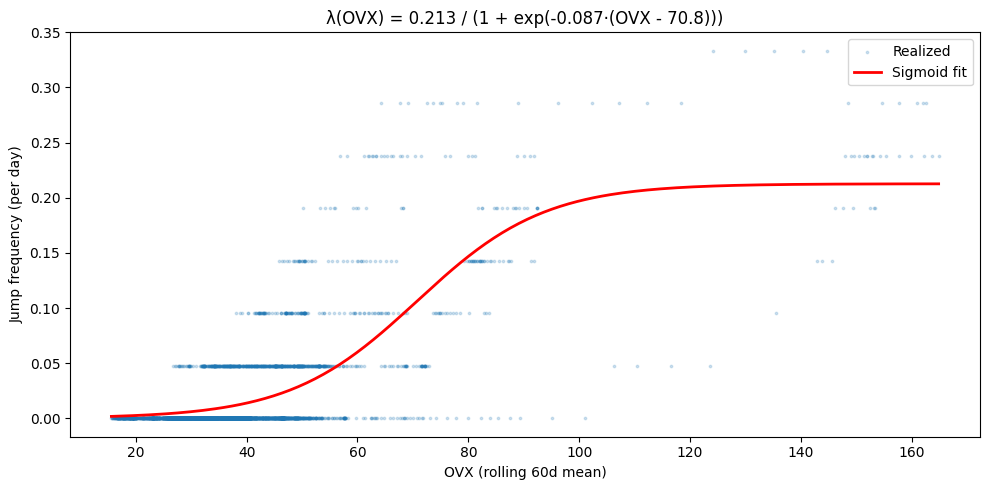

In [31]:

# 6. Plot fit
ovx_grid = np.linspace(df_fit['OVX_avg'].min(), df_fit['OVX_avg'].max(), 200)
fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(df_fit['OVX_avg'], df_fit['realized_lambda'], s=3, alpha=0.2, label='Realized')
ax.plot(ovx_grid, sigmoid(ovx_grid, *popt), 'r-', lw=2, label='Sigmoid fit')
ax.set_xlabel('OVX (rolling 60d mean)')
ax.set_ylabel('Jump frequency (per day)')
ax.set_title(f'λ(OVX) = {L:.3f} / (1 + exp(-{k:.3f}·(OVX - {x0:.1f})))')
ax.legend()
plt.tight_layout()
plt.show()

## 4. Calibrate eta (single jump size parameter)

Exponential jump distribution: one parameter eta controls both mean and variance.
- mu_J = -eta (mean jump size)
- sigma_J = eta (jump size dispersion)

In [14]:
# Conditional on a jump occurring in the next 21 days,
# what is the average worst daily return?
jumped = fit_df[fit_df['any_jump_next21'] == 1].copy()

# eta = mean absolute jump size
eta = -jumped['min_ret_next21'].mean()

print(f"eta = {eta:.4f}")
print(f"  -> mu_J = {-eta:.4f}")
print(f"  -> sigma_J = {eta:.4f}")
print(f"  (calibrated from {len(jumped)} observations with jumps)")

# For comparison: two-parameter estimates
mu_two_param = jumped['min_ret_next21'].mean()
sigma_two_param = jumped['min_ret_next21'].std()
print(f"\nTwo-parameter comparison:")
print(f"  mu_J = {mu_two_param:.4f}, sigma_J = {sigma_two_param:.4f}")

eta = 0.0793
  -> mu_J = -0.0793
  -> sigma_J = 0.0793
  (calibrated from 987 observations with jumps)

Two-parameter comparison:
  mu_J = -0.0793, sigma_J = 0.0615


## 5. Final Mapping Function

In [22]:
OVX_FLOOR = 0  # below this, no jumps

def ovx_to_jump_params(ovx_val):
    """Maps OVX to (lambda, mu_J, sigma_J) using logistic intensity + exponential jump size."""
    if np.isnan(ovx_val) or ovx_val < OVX_FLOOR:
        return 0.0, 0.0, 0.0

    prob = logistic(ovx_val, a_fit, b_fit)
    lam = -np.log(1 - np.clip(prob, 0, 0.999))

    return lam, -eta, eta

## 6. Parameter Table

In [26]:
print(f"{'OVX':>6s} {'lam':>8s} {'prob':>8s} {'mu_J':>8s} {'sig_J':>8s}")
for ovx_val in [25, 30, 35, 40, 50, 60, 80, 100, 150, 200]:
    l, m, s = ovx_to_jump_params(ovx_val)
    prob = 1 - np.exp(-l) if l > 0 else 0
    print(f"{ovx_val:6.0f} {l:8.3f} {prob:8.1%} {m:8.4f} {s:8.4f}")

   OVX      lam     prob     mu_J    sig_J
    25    0.080     7.7%  -0.0793   0.0793
    30    0.118    11.1%  -0.0793   0.0793
    35    0.171    15.7%  -0.0793   0.0793
    40    0.245    21.7%  -0.0793   0.0793
    50    0.481    38.2%  -0.0793   0.0793
    60    0.864    57.9%  -0.0793   0.0793
    80    2.053    87.2%  -0.0793   0.0793
   100    3.544    97.1%  -0.0793   0.0793
   150    6.908    99.9%  -0.0793   0.0793
   200    6.908    99.9%  -0.0793   0.0793


## 7. Visualize

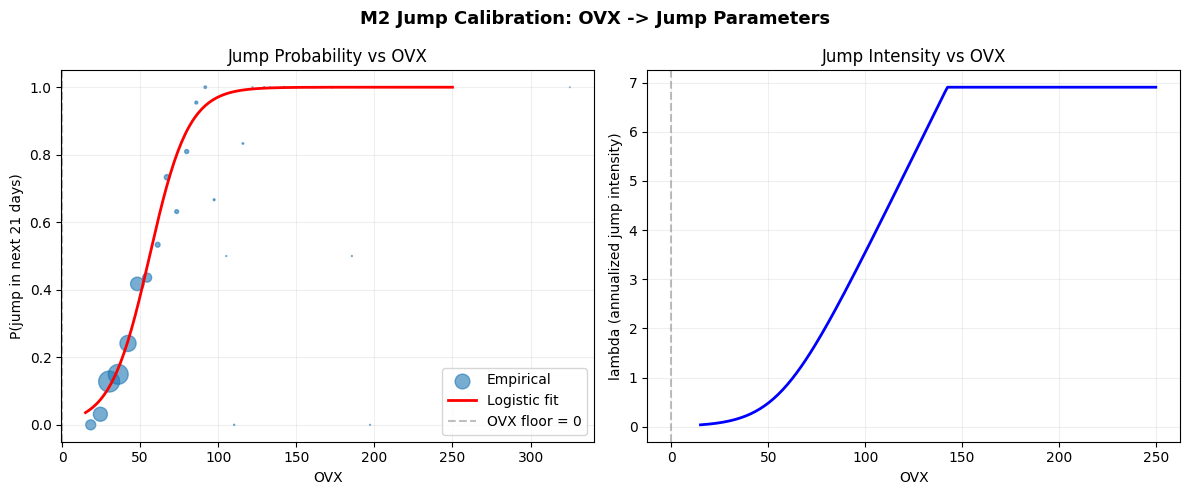

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot 1: Logistic fit
ovx_grid = np.linspace(15, 250, 200)
ax = axes[0]
ax.scatter(binned['ovx_mid'], binned['prob'], s=binned['n']/5, alpha=0.6, label='Empirical')
ax.plot(ovx_grid, logistic(ovx_grid, a_fit, b_fit), 'r-', lw=2, label='Logistic fit')
ax.axvline(OVX_FLOOR, color='gray', ls='--', alpha=0.5, label=f'OVX floor = {OVX_FLOOR}')
ax.set_xlabel('OVX')
ax.set_ylabel('P(jump in next 21 days)')
ax.set_title('Jump Probability vs OVX')
ax.legend()
ax.grid(True, alpha=0.2)

# Plot 2: Lambda vs OVX
ax = axes[1]
lam_grid = [ovx_to_jump_params(v)[0] for v in ovx_grid]
ax.plot(ovx_grid, lam_grid, 'b-', lw=2)
ax.axvline(OVX_FLOOR, color='gray', ls='--', alpha=0.5)
ax.set_xlabel('OVX')
ax.set_ylabel('lambda (annualized jump intensity)')
ax.set_title('Jump Intensity vs OVX')
ax.grid(True, alpha=0.2)

fig.suptitle('M2 Jump Calibration: OVX -> Jump Parameters', fontsize=13, fontweight='bold')
fig.tight_layout()
plt.savefig('jump_calibration.png', dpi=150, bbox_inches='tight')
plt.show()